In [1]:
import sys
sys.path.append("..")

In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Exploring Latent Spaces of Sentence Transformers
Thus far, looking at 
- self-similarity of datasets (noise introduced due to projection), 
- impact of dataset on our assessment,
- impact of n_projections choice on our assessment

Not sure what to make of the results tbh

In [2]:
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset

/Users/c/Library/Caches/pypoetry/virtualenvs/pesto-R9MfnoAy-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model_name = 'all-mpnet-base-v2'
max_seq_length = 384
model = SentenceTransformer(model_name)

In [3]:
dataset_name = "big_patent"
dataset = load_dataset(dataset_name, "a")

/Users/c/Library/Caches/pypoetry/virtualenvs/pesto-R9MfnoAy-py3.10/lib/python3.10/site-packages/datasets/load.py:1429: FutureWarning: The repository for big_patent contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/big_patent
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
Generating test split: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9675/9675 [00:05<00:00, 1889.16 examples/s]


In [132]:
dataset2 = load_dataset("gfissore/arxiv-abstracts-2021")

Generating train split: 1999486 examples [00:06, 300292.15 examples/s]


### TODO fix crappy test code

In [29]:
embedding1 = np.vstack([model.encode(dataset["test"][i]["abstract"]) for i in range(100)])
embedding2 = np.vstack([model.encode(dataset["test"][i]["abstract"]) for i in range(100,200)])
embedding3 = np.vstack([model.encode(dataset["test"][i]["abstract"]) for i in range(200,300)])
embedding4 = np.vstack([model.encode(dataset["test"][i]["abstract"]) for i in range(300)]) # 3x as large as others

In [31]:
from pesto import PESTO

In [136]:
other_embedding = np.vstack([model.encode(dataset2["train"][i]["abstract"]) for i in range(1000)])

In [137]:
embeddings = {0:embedding1, 1:embedding2, 2:embedding3, 3:embedding4, 4:other_embedding}

### TODO where is the random seed set? What is the expected/expectable range of our measure? Plus: Maybe we can compare landscape distributions rather than means?

In [ ]:
scores = dict()

In [138]:
projection_ns = [2**x for x in range(2,12)]
for n_projections in projection_ns:
    for i in sorted(embeddings.keys()):
        for j in sorted(embeddings.keys()):
            if i <= j and j == 4:
                if (i,j) not in scores:
                    scores[(i,j)] = list()
                metric = PESTO(max_homology_dim=2, normalize=False)
                score = metric.fit_transform(embeddings[i], embeddings[j], N=n_projections)
                scores[(i,j)].append(score)
                print(i, j, n_projections, score)

0 4 4 0.1251058974598485
1 4 4 0.13940973825304842
2 4 4 0.12655674272477654
3 4 4 0.2112422775068056
4 4 4 0.20297642380042022
0 4 8 0.1996359972405951
1 4 8 0.25784383276425915
2 4 8 0.16117780626101108
3 4 8 0.11240310561089953
4 4 8 0.1414145229169732
0 4 16 0.16472263453859967
1 4 16 0.16644641325946186
2 4 16 0.2025736136300889
3 4 16 0.1479662448333396
4 4 16 0.07015656584984684
0 4 32 0.15104398842544348
1 4 32 0.3164657305522483
2 4 32 0.10658207149663167
3 4 32 0.15550112134775815
4 4 32 0.12465795478113434
0 4 64 0.20818843429841502
1 4 64 0.14492667716567864
2 4 64 0.18560809416158303
3 4 64 0.16870776857846534
4 4 64 0.08997996519158198
0 4 128 0.1299675179201631
1 4 128 0.11221594107628542
2 4 128 0.15808314886977146
3 4 128 0.20458730718236012
4 4 128 0.16120412992830294
0 4 256 0.1590992594115131
1 4 256 0.12819166826879763
2 4 256 0.20066779855298766
3 4 256 0.13229292703908407
4 4 256 0.11488964268044823
0 4 512 0.34556994989195866
1 4 512 0.1465088191774014
2 4 512 0

In [139]:
df = pd.DataFrame.from_records(scores)
df["n_projections"] = projection_ns
df

,"(0, 0)","(0, 1)","(0, 2)","(0, 3)","(0, 4)","(1, 1)","(1, 2)","(1, 3)","(1, 4)","(2, 2)","(2, 3)","(2, 4)","(3, 3)","(3, 4)","(4, 4)",n_projections
0,0.133265,0.213670,0.109504,0.107292,0.125106,0.234116,0.217312,0.202818,0.139410,0.181121,0.128336,0.126557,0.133436,0.211242,0.202976,4
1,0.141486,0.149918,0.153894,0.244224,0.199636,0.094024,0.208337,0.085825,0.257844,0.095791,0.194042,0.161178,0.148594,0.112403,0.141415,8
2,0.206704,0.123864,0.101959,0.260236,0.164723,0.195116,0.105728,0.221427,0.166446,0.203126,0.120527,0.202574,0.116750,0.147966,0.070157,16
3,0.169137,0.094017,0.193311,0.127459,0.151044,0.133778,0.253347,0.286808,0.316466,0.120813,0.068791,0.106582,0.158146,0.155501,0.124658,32
4,0.439359,0.138083,0.259712,0.147003,0.208188,0.180935,0.199177,0.254804,0.144927,0.204828,0.151028,0.185608,0.210184,0.168708,0.089980,64
5,0.145875,0.192877,0.191512,0.209468,0.129968,0.205209,0.271549,0.079697,0.112216,0.224562,0.141172,0.158083,0.120493,0.204587,0.161204,128
6,0.175854,0.172737,0.216024,0.404684,0.159099,0.182664,0.214351,0.134109,0.128192,0.113854,0.146048,0.200668,0.156725,0.132293,0.114890,256
7,0.110348,0.291556,0.213198,0.135674,0.345570,0.141255,0.095964,0.058844,0.146509,0.190404,0.236363,0.219101,0.093292,0.152687,0.112507,512
8,0.192292,0.367260,0.225061,0.305060,0.075735,0.207022,0.213625,0.234428,0.206537,0.125891,0.138098,0.187367,0.212096,0.243421,0.191241,1024
9,0.179425,0.169019,0.222732,0.307435,0.174991,0.187146,0.153078,0.140029,0.249259,0.320448,0.200391,0.279654,0.133426,0.131366,0.182136,2048


In [140]:
df.to_csv("pesto_test.csv.gz")

### Plotting

In [81]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

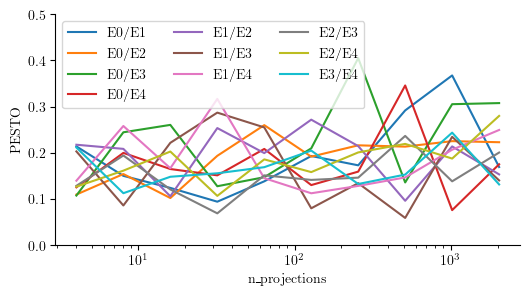

In [144]:
fig, ax = plt.subplots(1,1,figsize=(6,3))
sns.lineplot(df, x="n_projections", y=(0,1), ax=ax, label="E0/E1")
sns.lineplot(df, x="n_projections", y=(0,2), ax=ax, label="E0/E2")
sns.lineplot(df, x="n_projections", y=(0,3), ax=ax, label="E0/E3")
sns.lineplot(df, x="n_projections", y=(0,4), ax=ax, label="E0/E4")
sns.lineplot(df, x="n_projections", y=(1,2), ax=ax, label="E1/E2")
sns.lineplot(df, x="n_projections", y=(1,3), ax=ax, label="E1/E3")
sns.lineplot(df, x="n_projections", y=(1,4), ax=ax, label="E1/E4")
sns.lineplot(df, x="n_projections", y=(2,3), ax=ax, label="E2/E3")
sns.lineplot(df, x="n_projections", y=(2,4), ax=ax, label="E2/E4")
sns.lineplot(df, x="n_projections", y=(3,4), ax=ax, label="E3/E4")
sns.despine(fig)
ax.set_xscale("log")
ax.set_ylabel("PESTO")
ax.set_ylim(0,0.5)
plt.legend(ncol=3)

(0.0, 0.5)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


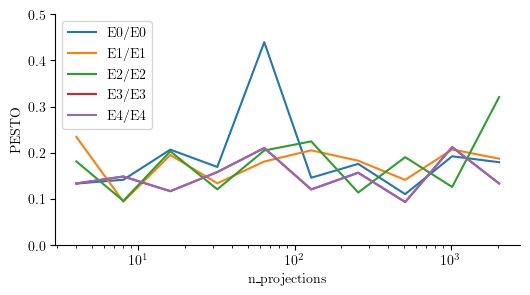

In [145]:
fig, ax = plt.subplots(1,1,figsize=(6,3))
sns.lineplot(df, x="n_projections", y=(0,0), ax=ax, label="E0/E0")
sns.lineplot(df, x="n_projections", y=(1,1), ax=ax, label="E1/E1")
sns.lineplot(df, x="n_projections", y=(2,2), ax=ax, label="E2/E2")
sns.lineplot(df, x="n_projections", y=(3,3), ax=ax, label="E3/E3")
sns.lineplot(df, x="n_projections", y=(3,3), ax=ax, label="E4/E4")
sns.despine(fig)
ax.set_xscale("log")
ax.set_ylabel("PESTO")
ax.set_ylim(0,0.5)